In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
import numpy as np
import seaborn as sns


In [2]:
# Load the dataset
tips = pd.read_csv('tips.csv')

# Display the first 5 rows of the data
tips.head()



,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
# check for missing values and data types
print(tips.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None


In [4]:
# Print some summary statistics for the dataset
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [5]:
# create a scatterplot of total bill amount vs. tip amount
sns.scatterplot(x="total_bill", y="tip", data=tips)
plt.title("Total Bill Amount vs. Tip Amount")
plt.show()

NameError: name 'sns' is not defined

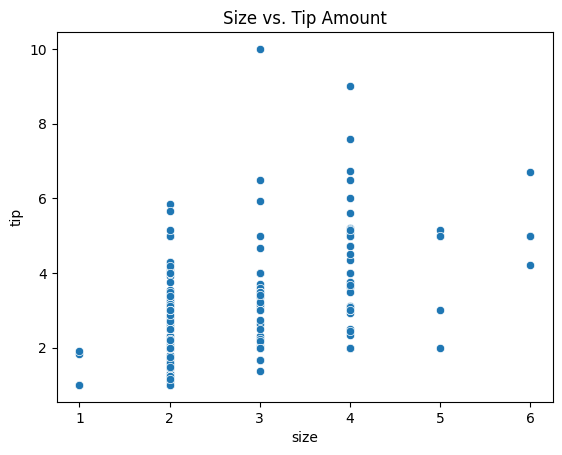

In [37]:
# create a scatterplot of size vs. tip amount
sns.scatterplot(x="size", y="tip", data=tips)
plt.title("Size vs. Tip Amount")
plt.show()

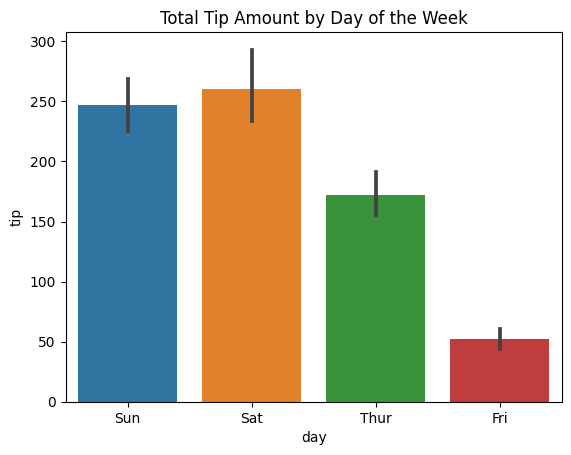

In [12]:
# create a barplot of average tip amount by day of the week
sns.barplot(x="day", y="tip", data=tips, estimator=sum)
plt.title("Total Tip Amount by Day of the Week")
plt.show()

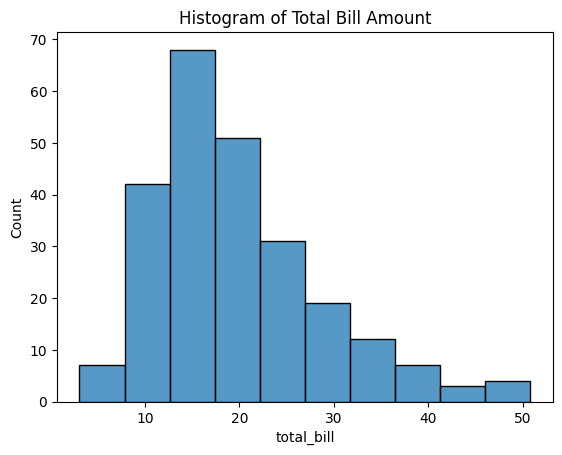

In [13]:
# create a histogram of total bill amount
sns.histplot(x="total_bill", data=tips, bins=10)
plt.title("Histogram of Total Bill Amount")
plt.show()

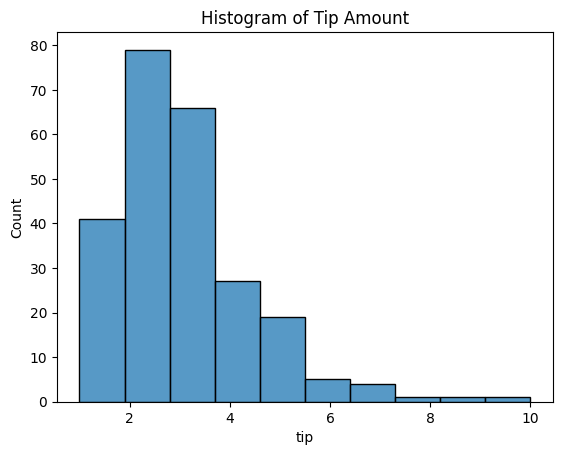

In [17]:
# create a histogram of tip amount
sns.histplot(x="tip", data=tips, bins=10)
plt.title("Histogram of Tip Amount")
plt.show()

/var/folders/t9/xzq_p4jn637gk3j8dlymkptc0000gn/T/ipykernel_79687/3609019465.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = tips.corr()


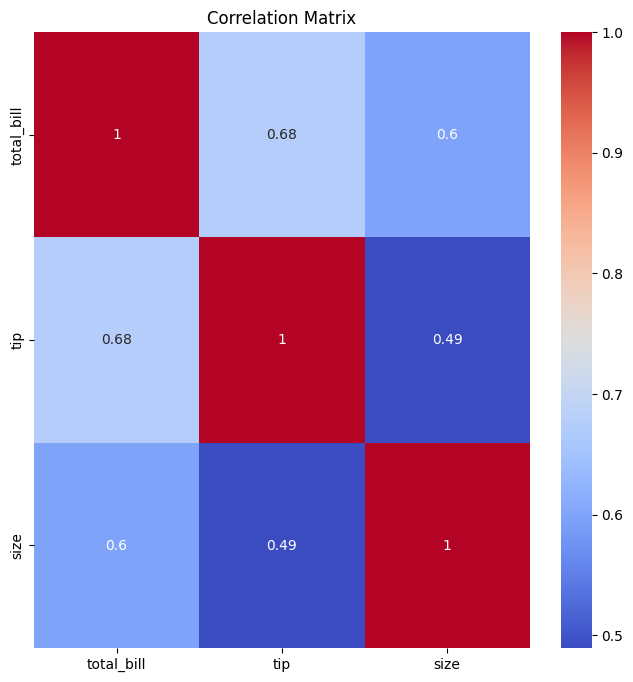

In [19]:
# calculate correlation matrix
corr = tips.corr()

# plot the correlation matrix as a heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.title('Correlation Matrix')
plt.show()

In [6]:
le = LabelEncoder()

# Encode 'sex' column
tips['sex'] = le.fit_transform(tips['sex'])

# Encode 'smoker' column
tips['smoker'] = le.fit_transform(tips['smoker'])

# Encode 'day' column
tips['day'] = le.fit_transform(tips['day'])

# Encode 'time' column
tips['time'] = le.fit_transform(tips['time'])

tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,0,2
1,10.34,1.66,1,0,2,0,3
2,21.01,3.50,1,0,2,0,3
3,23.68,3.31,1,0,2,0,2
4,24.59,3.61,0,0,2,0,4


In [7]:
# select the feature columns and the target column
X = tips.drop("tip", axis=1)
y = tips["tip"]

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [8]:
# fit a linear regression model to the training data
lr = LinearRegression()
lr.fit(X_train, y_train)

# Access coefficients
print(lr.coef_)

X.head()

[ 0.09396463  0.03271041 -0.19174368 -0.00682977  0.06122632  0.24030326]


,total_bill,sex,smoker,day,time,size
0,16.99,0,0,2,0,2
1,10.34,1,0,2,0,3
2,21.01,1,0,2,0,3
3,23.68,1,0,2,0,2
4,24.59,0,0,2,0,4


In [9]:
# make predictions on the testing data
y_pred = lr.predict(X_test)

y_pred

array([2.98575218, 1.94061325, 3.90398163, 3.84498032, 2.1680261 ,
       2.60582699, 3.65155039, 2.31090817, 2.50534068, 2.3509249 ,
       2.83515653, 2.13537228, 2.1389529 , 2.2854076 , 1.84415015,
       3.13003355, 2.9775778 , 3.14430016, 2.63638097, 5.76225288,
       3.51539752, 3.30404608, 2.24355298, 2.02073543, 3.09625338,
       2.26938652, 2.0815602 , 3.27434496, 3.14662672, 6.60403271,
       4.93408016, 1.65891577, 3.2774898 , 2.83817187, 2.91871607,
       3.8815044 , 2.0688538 , 5.47790762, 2.37480412, 3.06180769,
       2.11094147, 2.50259602, 3.36699633, 2.29479093, 1.95079059,
       0.94708728, 1.89400456, 3.11987541, 1.8813126 ])

In [11]:
# calculate the mean squared error of the predictions
mse = mean_squared_error(y_test, y_pred)
print("Mean squared error: {:.2f}".format(mse))


Mean squared error: 0.69


In [12]:
# compare MSE to MSE based on a naive predictive model

# Calculate the mean tip value
mean_tip = tips['tip'].mean()

# Generate the predictions using the mean tip value
predictions = [mean_tip] * len(tips)

# Calculate the mean squared error
mse_naive = ((tips['tip'] - predictions) ** 2).mean()

print("Mean squared error: {:.2f}".format(mse_naive))

Mean squared error: 1.91


In [15]:

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print('RMSE:', rmse)

RMSE: 0.8335544185167343


In [16]:
from sklearn.metrics import r2_score
# Compute the R-squared value
r2 = r2_score(y_test, y_pred)

print("R-squared: ", r2)

R-squared:  0.4441368826121931


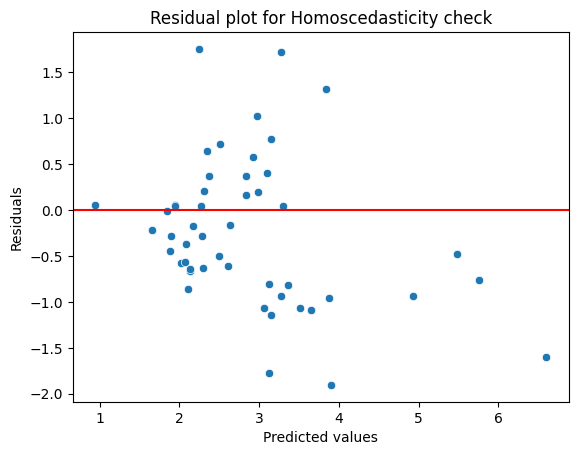

In [19]:
# Create a linear regression model
#X = tips[["total_bill", "size"]]
#y = tips["tip"]
#lr = LinearRegression().fit(X, y)

# Make predictions and calculate residuals
#y_pred = lr.predict(X)
#residuals = y - y_pred

residuals = y_test - y_pred

# Plot residuals against predicted values
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residual plot for Homoscedasticity check")
plt.show()

In [20]:
from scipy.stats import shapiro

# perform Shapiro-Wilk test on residuals
stat, p = shapiro(residuals)

# interpret the test
alpha = 0.05
print(p)
if p > alpha:
    print('Residuals are normally distributed (fail to reject H0)')
else:
    print('Residuals are not normally distributed (reject H0)')

0.4451647996902466
Residuals are normally distributed (fail to reject H0)
